# Pauli-Basis TEBD for a Local Lindbladian

This notebook evolves a density matrix in the Pauli basis under a disordered XXZ Hamiltonian plus local dephasing jumps. The point is to show how local Lindblad terms fit the same TEBD workflow as local Hamiltonian terms once everything is written in operator space.

The comparison below uses the same disordered XXZ chain with:

- `gamma = 0`: closed-system evolution
- `gamma > 0`: local dephasing jumps `L_j = sqrt(gamma) S^z_j`

The local jumps are on-site, so each Strang-split TEBD update only needs a local two-site Lindbladian gate in the Pauli basis.


In [1]:
using Random
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using MPSToolkit

default(size=(960, 680), linewidth=2, markersize=4, legend=:best)


## Local Lindbladian building blocks

Two package helpers are the key ingredients here:

- `pauli_lindblad_generator(h, jumps)`: builds the dense local Lindbladian generator in the Pauli basis
- `pauli_gate_from_lindbladian(h, jumps, dt)`: exponentiates that generator into one local TEBD gate

The only subtle part in a Strang decomposition is the jump scaling. If one local Lindblad term gets a Strang weight `w`, then:

- the Hamiltonian part scales as `w * h`
- each jump operator scales as `sqrt(w) * L`

because the dissipator is quadratic in the jump amplitude.


In [2]:
function disordered_xxz_bond_hamiltonian(nsites, bond, fields; Jxy::Real=1.0, Delta::Real=1.0)
    spins = spinhalf_matrices()
    interaction =
        Jxy * kron(spins.Sx, spins.Sx) +
        Jxy * kron(spins.Sy, spins.Sy) +
        Delta * kron(spins.Sz, spins.Sz)

    left_weight = bond == 1 ? 1.0 : 0.5
    right_weight = bond == (nsites - 1) ? 1.0 : 0.5
    field_term =
        left_weight * fields[bond] * kron(spins.Sz, spins.I) +
        right_weight * fields[bond + 1] * kron(spins.I, spins.Sz)

    return ComplexF64.(interaction + field_term)
end

function disordered_xxz_lindblad_term(nsites, bond, fields; Jxy::Real=1.0, Delta::Real=1.0, gamma::Real=0.0, weight::Real=1.0)
    spins = spinhalf_matrices()
    scaled_hamiltonian = weight * disordered_xxz_bond_hamiltonian(nsites, bond, fields; Jxy=Jxy, Delta=Delta)

    left_share = bond == 1 ? 1.0 : 0.5
    right_share = bond == (nsites - 1) ? 1.0 : 0.5
    jumps = Matrix{ComplexF64}[]

    if gamma > 0
        if left_share > 0
            push!(jumps, sqrt(weight * gamma * left_share) * kron(spins.Sz, spins.I))
        end
        if right_share > 0
            push!(jumps, sqrt(weight * gamma * right_share) * kron(spins.I, spins.Sz))
        end
    end

    return (; hamiltonian=scaled_hamiltonian, jumps=jumps)
end

function neel_density_state(sites)
    up_density = [1 / sqrt(2), 0.0, 0.0, 1 / sqrt(2)]
    dn_density = [1 / sqrt(2), 0.0, 0.0, -1 / sqrt(2)]
    tensors = ITensor[]
    for (site_index, site) in enumerate(sites)
        tensor = ITensor(site)
        coeffs = isodd(site_index) ? up_density : dn_density
        for basis_index in 1:4
            tensor[site => basis_index] = coeffs[basis_index]
        end
        push!(tensors, tensor)
    end
    return MPS(tensors)
end

function local_sz_operators(sites)
    nsites = length(sites)
    operators = MPS[]
    for site in 1:nsites
        labels = [j == site ? "Z" : "I" for j in 1:nsites]
        push!(operators, pauli_basis_state(sites, labels; coefficient=0.5))
    end
    return operators
end

function imbalance_and_profile(rho_state, sz_ops)
    profile = [real(inner(op, rho_state)) for op in sz_ops]
    imbalance = (2 / length(profile)) * sum(((-1)^(site - 1)) * profile[site] for site in 1:length(profile))
    return imbalance, profile
end

function run_lindblad_tebd(fields; Jxy::Real=1.0, Delta::Real=1.0, gamma::Real=0.0, dt::Real, tmax::Real, sample_every::Integer, maxdim::Integer, cutoff::Real, entropy_bond::Integer)
    nsites = length(fields)
    sites = pauli_siteinds(nsites)
    rho = neel_density_state(sites)
    sz_ops = local_sz_operators(sites)

    evolution = tebd_strang_evolution(
        nsites,
        dt;
        local_hamiltonian=(bond, weight) -> disordered_xxz_lindblad_term(nsites, bond, fields; Jxy=Jxy, Delta=Delta, gamma=gamma, weight=weight),
        map_hamiltonian=(term, step_dt) -> pauli_gate_from_lindbladian(term.hamiltonian, term.jumps, step_dt),
        maxdim=maxdim,
        cutoff=cutoff,
    )

    nsteps = round(Int, tmax / dt)
    measure_steps = Set(collect(0:sample_every:nsteps))
    times = Float64[]
    imbalances = Float64[]
    purities = Float64[]
    entropies = Float64[]
    maxlinkdims = Int[]
    final_profile = zeros(Float64, nsites)

    for step in 0:nsteps
        if step in measure_steps
            imbalance_value, profile = imbalance_and_profile(rho, sz_ops)
            push!(times, step * dt)
            push!(imbalances, imbalance_value)
            push!(purities, real(inner(rho, rho)))
            push!(entropies, bond_entropy(rho, entropy_bond))
            push!(maxlinkdims, maxlinkdim(rho))
            final_profile .= profile
        end
        step == nsteps && break
        evolve!(rho, evolution)
    end

    return (; times, imbalances, purities, entropies, maxlinkdims, final_profile, gamma, fields)
end


run_lindblad_tebd (generic function with 1 method)

## Parameters

This is a stronger-disorder chain so the closed-system run keeps substantial memory of the N'eel initial condition, while the dephasing run steadily loses it.

Default choices:

- `nsites = 12`: small enough for an operator-space example, but large enough that entanglement growth matters
- `W = 8.0`: strong disorder in the XXZ fields
- `dt = 0.05`, `tmax = 10.0`: moderate real-time TEBD window
- `maxdim = 96`: shared compression cap for both runs
- `gamma_dephasing = 0.2`: local dephasing strength in `L_j = sqrt(gamma) S^z_j`


In [3]:
Random.seed!(21)

nsites = 12
W = 8.0
dt = 0.05
tmax = 10.0
sample_every = 4
maxdim = 96
cutoff = 1e-9
entropy_bond = nsites ÷ 2
Jxy = 1.0
Delta = 1.0
gamma_dephasing = 0.2

base_fields = 2 .* rand(Random.default_rng(), nsites) .- 1
fields = W .* base_fields

closed_run = run_lindblad_tebd(
    fields;
    Jxy=Jxy,
    Delta=Delta,
    gamma=0.0,
    dt=dt,
    tmax=tmax,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    entropy_bond=entropy_bond,
)

dephased_run = run_lindblad_tebd(
    fields;
    Jxy=Jxy,
    Delta=Delta,
    gamma=gamma_dephasing,
    dt=dt,
    tmax=tmax,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    entropy_bond=entropy_bond,
)

println("closed final imbalance = ", closed_run.imbalances[end])
println("dephased final imbalance = ", dephased_run.imbalances[end])
println("closed final purity = ", closed_run.purities[end])
println("dephased final purity = ", dephased_run.purities[end])
println("closed max bond dimension = ", maximum(closed_run.maxlinkdims))
println("dephased max bond dimension = ", maximum(dephased_run.maxlinkdims))


closed final imbalance = 0.00913502347691923
dephased final imbalance = 0.00787209499499934
closed final purity = 0.9999986973352217
dephased final purity = 0.10027074668622131
closed max bond dimension = 67
dephased max bond dimension = 40


## Dynamical signatures of local dephasing

The closed run is still unitary in Liouville space, so its purity stays at `1`. The dephasing run is genuinely dissipative, so you should see:

- lower imbalance at late times
- purity decay away from `1`
- reduced operator-space entanglement growth compared with the closed run


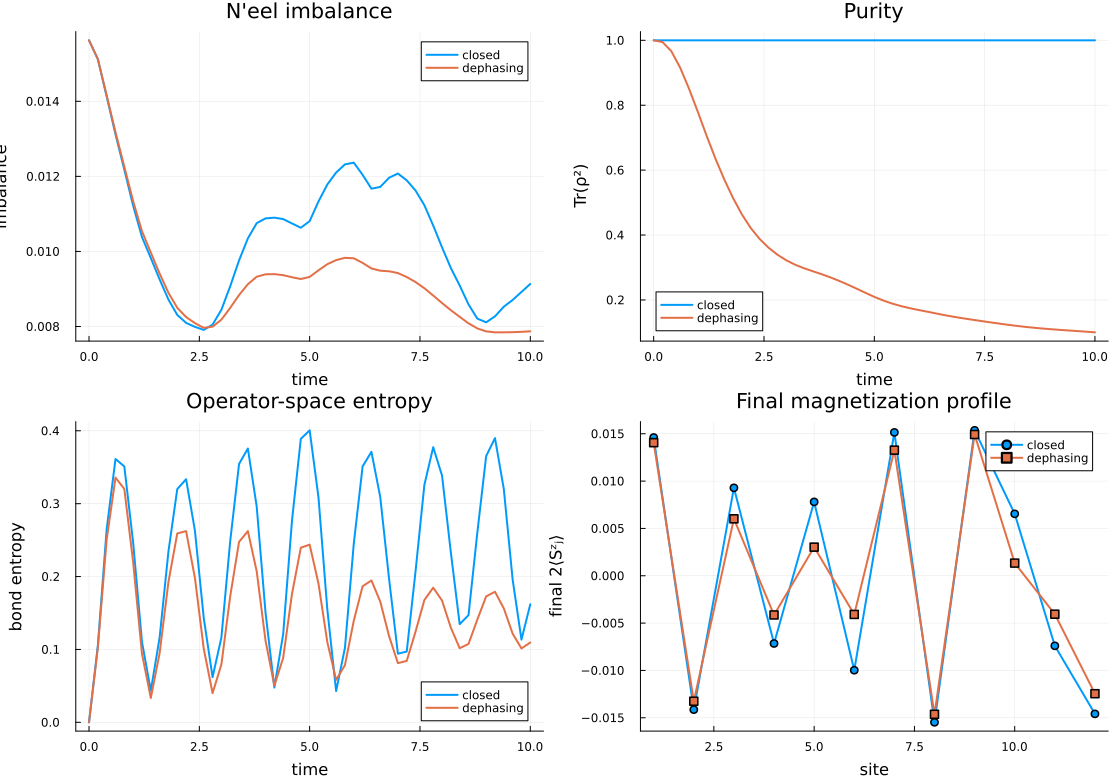

In [4]:
lindblad_plots = plot(layout=(2, 2), size=(1120, 780))

plot!(
    lindblad_plots[1],
    closed_run.times,
    closed_run.imbalances;
    label="closed",
    xlabel="time",
    ylabel="imbalance",
    title="N'eel imbalance",
)
plot!(
    lindblad_plots[1],
    dephased_run.times,
    dephased_run.imbalances;
    label="dephasing",
)

plot!(
    lindblad_plots[2],
    closed_run.times,
    closed_run.purities;
    label="closed",
    xlabel="time",
    ylabel="Tr(ρ²)",
    title="Purity",
)
plot!(
    lindblad_plots[2],
    dephased_run.times,
    dephased_run.purities;
    label="dephasing",
)

plot!(
    lindblad_plots[3],
    closed_run.times,
    closed_run.entropies;
    label="closed",
    xlabel="time",
    ylabel="bond entropy",
    title="Operator-space entropy",
)
plot!(
    lindblad_plots[3],
    dephased_run.times,
    dephased_run.entropies;
    label="dephasing",
)

plot!(
    lindblad_plots[4],
    1:nsites,
    2 .* closed_run.final_profile;
    marker=:circle,
    label="closed",
    xlabel="site",
    ylabel="final 2⟨Sᶻⱼ⟩",
    title="Final magnetization profile",
)
plot!(
    lindblad_plots[4],
    1:nsites,
    2 .* dephased_run.final_profile;
    marker=:square,
    label="dephasing",
)

display(lindblad_plots)


## What this notebook is showing

This is not a Monte Carlo quantum-jump simulation. It is deterministic Lindblad evolution in operator space:

- the density matrix is stored as a Pauli-basis `MPS`
- each local TEBD gate is the exponential of a local Lindbladian generator
- local jump operators fit naturally because the corresponding dissipators remain local

If you want to extend this, the next natural steps are:

- average over many disorder realizations
- try other local jumps, such as amplitude damping or local loss
- compare closed, dephasing, and driven-dissipative runs at the same `maxdim`
